<a href="https://colab.research.google.com/github/aberno2000/course_practices/blob/main/practical_task_10_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget 'https://storage.yandexcloud.net/academy.ai/practica/fake_news.csv'

--2025-10-12 17:17:44--  https://storage.yandexcloud.net/academy.ai/practica/fake_news.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30696129 (29M) [text/csv]
Saving to: ‘fake_news.csv’

fake_news.csv       100%[===================>]  29.27M  17.4MB/s    in 1.7s    

2025-10-12 17:17:46 (17.4 MB/s) - ‘fake_news.csv’ saved [30696129/30696129]



In [ ]:
import pandas
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pandas.read_csv("./fake_news.csv")

In [ ]:
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [ ]:
df.shape

(6335, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


In [ ]:
# Combine title and text for better features
import re

df['content'] = df['title'] + ' ' + df['text']

# Basic text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join(text.split())
    return text

# Apply cleaning
df['cleaned_content'] = df['content'].apply(clean_text)

print("Text cleaning completed!")
print("Sample cleaned text:")
print(df['cleaned_content'].iloc[0][:200] + "...")

Text cleaning completed!
Sample cleaned text:
you can smell hillarys fear daniel greenfield a shillman journalism fellow at the freedom center is a new york writer focusing on radical islam in the final stretch of the election hillary rodham clin...


In [ ]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,           # Keep top 5000 features
    stop_words='english',        # Remove English stopwords
    ngram_range=(1, 2),          # Use unigrams and bigrams
    max_df=0.7,                  # Ignore terms that appear in >70% of documents
    min_df=5,                    # Ignore terms that appear in <5 documents
    lowercase=True,              # Convert to lowercase
    use_idf=True,                # Use IDF weighting
    smooth_idf=True              # Smooth IDF weights
)

# Fit and transform the text data
X_tfidf = tfidf_vectorizer.fit_transform(df['cleaned_content'])
y = df['label']

print("TF-IDF transformation completed!")
print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Number of features: {len(tfidf_vectorizer.get_feature_names_out())}")

TF-IDF transformation completed!
TF-IDF matrix shape: (6335, 5000)
Number of features: 5000


In [ ]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintain label distribution in splits
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Training labels distribution:\n{y_train.value_counts()}")
print(f"Testing labels distribution:\n{y_test.value_counts()}")

Training set shape: (5068, 5000)
Testing set shape: (1267, 5000)
Training labels distribution:
label
REAL    2537
FAKE    2531
Name: count, dtype: int64
Testing labels distribution:
label
REAL    634
FAKE    633
Name: count, dtype: int64


In [ ]:
# Initialize Passive Aggressive Classifier
pac = PassiveAggressiveClassifier(
    C=1.0,              # Regularization parameter
    max_iter=1000,      # Maximum iterations
    random_state=42,    # Random state for reproducibility
    early_stopping=True, # Stop early if convergence
    validation_fraction=0.1, # Fraction of training data for validation
    n_iter_no_change=5  # Stop if no improvement for 5 iterations
)

# Train the model
pac.fit(X_train, y_train)

print("Passive Aggressive Classifier training completed!")

Passive Aggressive Classifier training completed!


In [ ]:
# Make predictions
y_pred = pac.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\n📈 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

🎯 Accuracy: 0.9274

📊 Classification Report:
              precision    recall  f1-score   support

        FAKE       0.94      0.91      0.93       633
        REAL       0.92      0.94      0.93       634

    accuracy                           0.93      1267
   macro avg       0.93      0.93      0.93      1267
weighted avg       0.93      0.93      0.93      1267


📈 Confusion Matrix:
[[578  55]
 [ 37 597]]


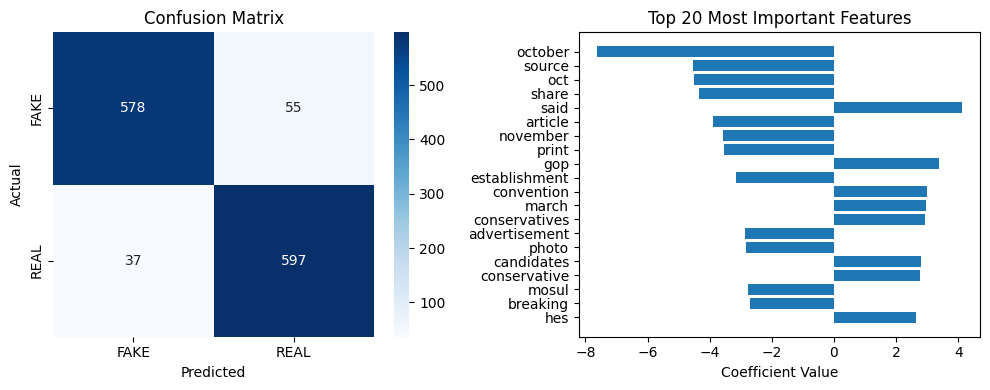

In [ ]:
# Plot confusion matrix
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Feature importance (top features)
plt.subplot(1, 2, 2)
feature_names = tfidf_vectorizer.get_feature_names_out()
coef = pac.coef_.toarray()[0] if hasattr(pac.coef_, 'toarray') else pac.coef_[0]

# Get top 10 features for each class
top_indices = np.argsort(np.abs(coef))[-20:]
top_features = [feature_names[i] for i in top_indices]
top_scores = coef[top_indices]

plt.barh(range(len(top_features)), top_scores)
plt.yticks(range(len(top_features)), top_features)
plt.title('Top 20 Most Important Features')
plt.xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

In [ ]:
def predict_news(texts):
    """
    Predict whether new news articles are fake or real
    """
    # Clean the new texts
    cleaned_texts = [clean_text(text) for text in texts]

    # Transform using the fitted TF-IDF vectorizer
    text_tfidf = tfidf_vectorizer.transform(cleaned_texts)

    # Make predictions
    predictions = pac.predict(text_tfidf)
    prediction_scores = pac.decision_function(text_tfidf)

    # Display results
    results = []
    for i, text in enumerate(texts):
        confidence = abs(prediction_scores[i])
        result = {
            'text': text[:100] + '...' if len(text) > 100 else text,
            'prediction': predictions[i],
            'confidence': f"{confidence:.4f}",
            'score': prediction_scores[i]
        }
        results.append(result)

    results_df = pd.DataFrame(results)
    display(results_df)
    return results

# Test with sample news
sample_news = [
    "Breaking news: Scientists discover new breakthrough in renewable energy technology that could change the world",
    "SHOCKING: Celebrity reveals secret alien conspiracy that government has been hiding for decades",
    "The stock market showed moderate gains today as investors responded to positive economic indicators",
    "You won't believe what this one simple trick can do to your life! Experts are amazed!"
]

print("🔍 Predicting sample news articles:")
predictions = predict_news(sample_news)

🔍 Predicting sample news articles:


,text,prediction,confidence,score
0,Breaking news: Scientists discover new breakth...,FAKE,3.1867,-3.186666
1,SHOCKING: Celebrity reveals secret alien consp...,FAKE,1.7547,-1.754722
2,The stock market showed moderate gains today a...,FAKE,0.2559,-0.255935
3,You won't believe what this one simple trick c...,FAKE,0.2475,-0.247531
